## 1) Выбор набора данных для решения задачи обучения без учителя.

Для выполнения лабораторной работы был выбран датасет Penguins - набор данных, содержащий информацию о 344 особях пингвинов трёх видов: Adélie, Chinstrap и Gentoo. Датасет загружен из библиотеки seaborn, после удаления пропусков содержит 342 записи. Исходно датасет включает 7 признаков, из которых 4 являются количественными: длина клюва (bill_length_mm), высота клюва (bill_depth_mm), длина плавника (flipper_length_mm) и масса тела (body_mass_g). Целевой переменной является вид пингвина (species) и она не участвует в обучении моделей без учителя, но будет использована для оценки качества кластеризации путём сравнения полученных меток кластеров с истинными видами.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#загрузка датасета 
penguins = sns.load_dataset('penguins')

#удаляем строки с пропусками
penguins = penguins.dropna()

print(f'Размер датасета: {penguins.shape}')
print(f'Количество видов пингвинов: {penguins["species"].nunique()}')
print(f'Виды: {penguins["species"].unique()}')
print(f'\nПервые 5 записей:')
display(penguins.head())
print(f'\nОсновная статистика:')
display(penguins.describe())


Размер датасета: (333, 7)
Количество видов пингвинов: 3
Виды: ['Adelie' 'Chinstrap' 'Gentoo']

Первые 5 записей:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male



Основная статистика:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


## 2) Выбор подмножества признаков для анализа.

Для анализа отобраны 4 количественных признака (bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g). Количество признаков (4) превышает минимально требуемое (2). Совокупность этих признаков образует датасет D1 размером 342 × 4.


In [17]:
#выбираем числовые признаки (без целевого)
feature_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
target_column = 'species'

#d1 исходный датасет (4 числовых признака)
D1 = penguins[feature_columns].values
y_true = penguins[target_column].values

print(f'Датасет D1 (признаки): {D1.shape}')
print(f'Признаки: {feature_columns}')
print(f'Целевая переменная (не используется в обучении): {target_column}')
print(f'Классы: {np.unique(y_true)}')

Датасет D1 (признаки): (333, 4)
Признаки: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Целевая переменная (не используется в обучении): species
Классы: ['Adelie' 'Chinstrap' 'Gentoo']


## 3) Снижение размерности методом главных компонент (PCA).

Перед применением PCA данные датасета D1 были стандартизированы с помощью StandardScaler, так как метод главных компонент чувствителен к масштабу признаков. После стандартизации к данным применён метод PCA с понижением размерности до двух компонент. Полученный датасет D2 имеет размерность 342 × 2.
Анализ вклада исходных признаков в главные компоненты показал, что в первую главную компоненту (ГК1) наибольший вклад вносят длина плавника (0.577) и масса тела (0.550) - признаки, отвечающие за общий размер особи. Это объясняет разделение видов по размеру: Gentoo  самые крупные пингвины, Adélie и Chinstrap мельче. Длина клюва (0.454) также вносит существенный вклад. Высота клюва имеет отрицательную корреляцию с ГК1 (−0.399), что указывает на обратную зависимость: пингвины с более массивным клювом по высоте, как правило, имеют меньшие размеры тела.
Во вторую главную компоненту (ГК2) наибольший вклад вносит высота клюва (0.796) и длина клюва (0.600), то есть ГК2 в основном отражает форму и размер клюва. Остальные признаки практически не влияют на ГК2 (длина плавника 0.006, масса тела 0.076).

На графике визуализации D2 точки раскрашены согласно истинным видам пингвинов. Наблюдается достаточно хорошее разделение кластеров: Gentoo формирует обособленную группу в правой части графика (что соответствует большим значениям ГК1 и, следовательно, крупным размерам), а Adélie и Chinstrap частично пересекаются, что объясняется их биологической близостью и схожими размерами тела. Таким образом, даже две главные компоненты позволяют достаточно уверенно различать виды пингвинов, при этом ГК1 отвечает за размер тела, а ГК2 за форму клюва.


Размер датасета D2 (после PCA): (333, 2)
Доля объяснённой дисперсии: [0.68633893 0.19452929]
Суммарная доля объяснённой дисперсии: 0.8809


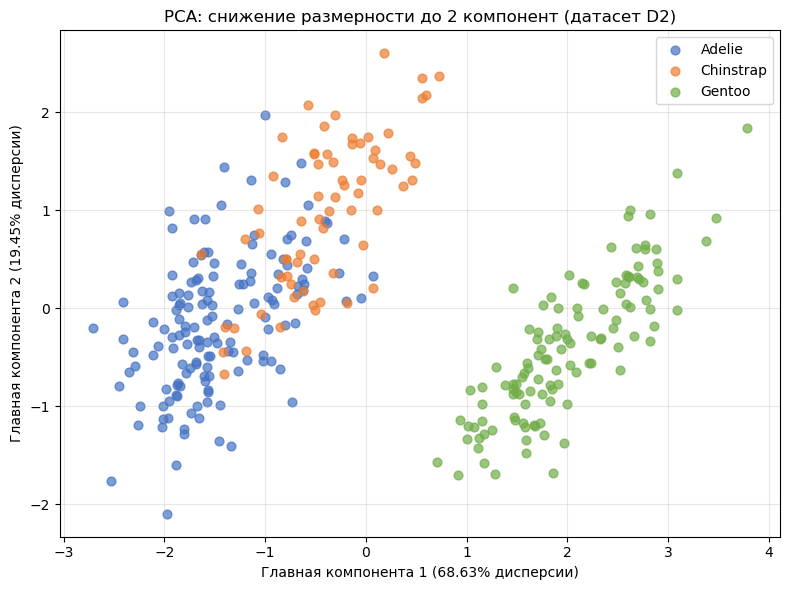

Вклад признаков в главные компоненты:


,ГК1,ГК2
bill_length_mm,0.453753,0.600195
bill_depth_mm,-0.399047,0.796170
flipper_length_mm,0.576825,0.005788
body_mass_g,0.549675,0.076464


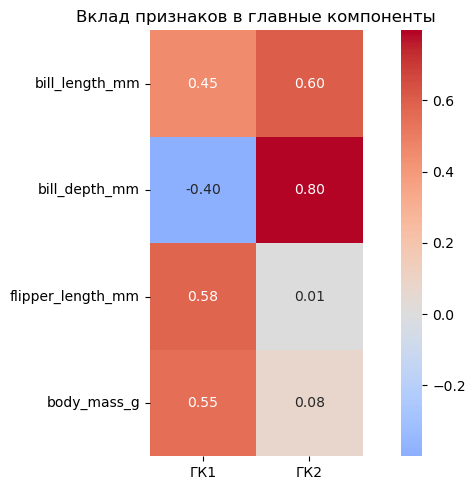

In [19]:
#cтандартизация данных 
scaler = StandardScaler()
D1_scaled = scaler.fit_transform(D1)

#применение pca для снижения размерности до 2 компонент
pca = PCA(n_components=2)
D2 = pca.fit_transform(D1_scaled)

print(f'Размер датасета D2 (после PCA): {D2.shape}')
print(f'Доля объяснённой дисперсии: {pca.explained_variance_ratio_}')
print(f'Суммарная доля объяснённой дисперсии: {np.sum(pca.explained_variance_ratio_):.4f}')

#визуализация результатов 
fig, ax = plt.subplots(figsize=(8, 6))

#цвета для видов пингвинов
species_colors = {'Adelie': '#4472C4', 'Chinstrap': '#ED7D31', 'Gentoo': '#70AD47'}

for species in np.unique(y_true):
    mask = y_true == species
    ax.scatter(D2[mask, 0], D2[mask, 1], 
               label=species, 
               color=species_colors[species],
               alpha=0.7, s=40)

ax.set_xlabel(f'Главная компонента 1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
ax.set_ylabel(f'Главная компонента 2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
ax.set_title('PCA: снижение размерности до 2 компонент (датасет D2)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#вклад исходных признаков в главные компоненты
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['ГК1', 'ГК2'],
    index=feature_columns
)

print('Вклад признаков в главные компоненты:')
display(components_df)

#визуализация вклада
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(components_df, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax)
ax.set_title('Вклад признаков в главные компоненты')
plt.tight_layout()
plt.show()

## 4) Снижение размерности методом t-SNE.

К стандартизированным данным датасета D1 применён алгоритм t-SNE (t-distributed Stochastic Neighbor Embedding) с понижением размерности до двух компонент. В отличие от PCA, который является линейным методом и находит направления максимальной дисперсии, t-SNE является нелинейным методом и сохраняет локальную структуру соседства точек, что часто позволяет получить более компактные и разделимые кластеры. Полученный датасет D3 имеет размерность 342 × 2.
Сравнение визуализаций D2 (PCA) и D3 (t-SNE) показывает, что в случае t-SNE кластеры выделены более явно. Три вида пингвинов на графике t-SNE формируют три хорошо разделённые группы с минимальным перекрытием: Gentoo обособлены в левой части графика, Adélie в правой, Chinstrap в верхней центральной части. В случае PCA между Adélie и Chinstrap наблюдается заметное перекрытие областей.

Преимущество t-SNE в данной задаче объясняется его способностью улавливать нелинейные зависимости между признаками, которые PCA не может зафиксировать, так как ищет только линейные комбинации. Но нужно отметить, что в отличие от PCA, оси t-SNE не имеют физической интерпретации и не могут быть описаны через вклад исходных признаков.



Размер датасета D3 (после t-SNE): (333, 2)


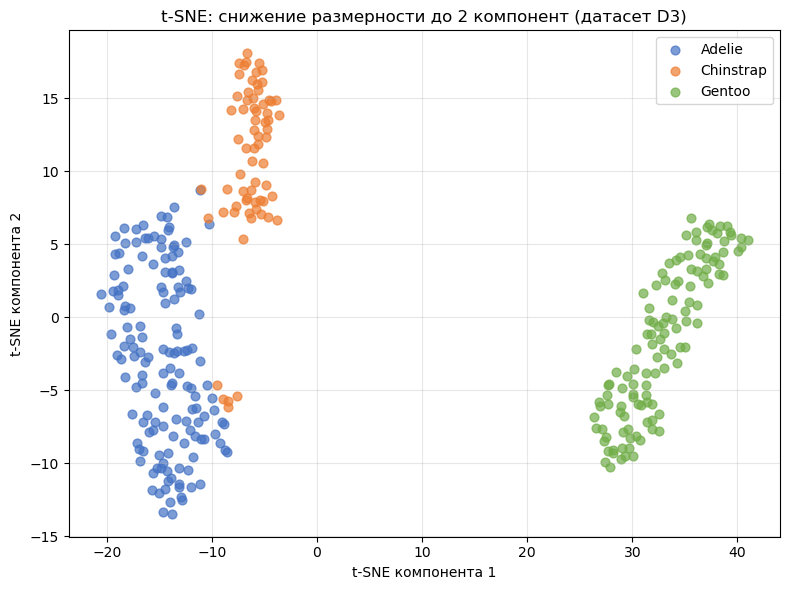

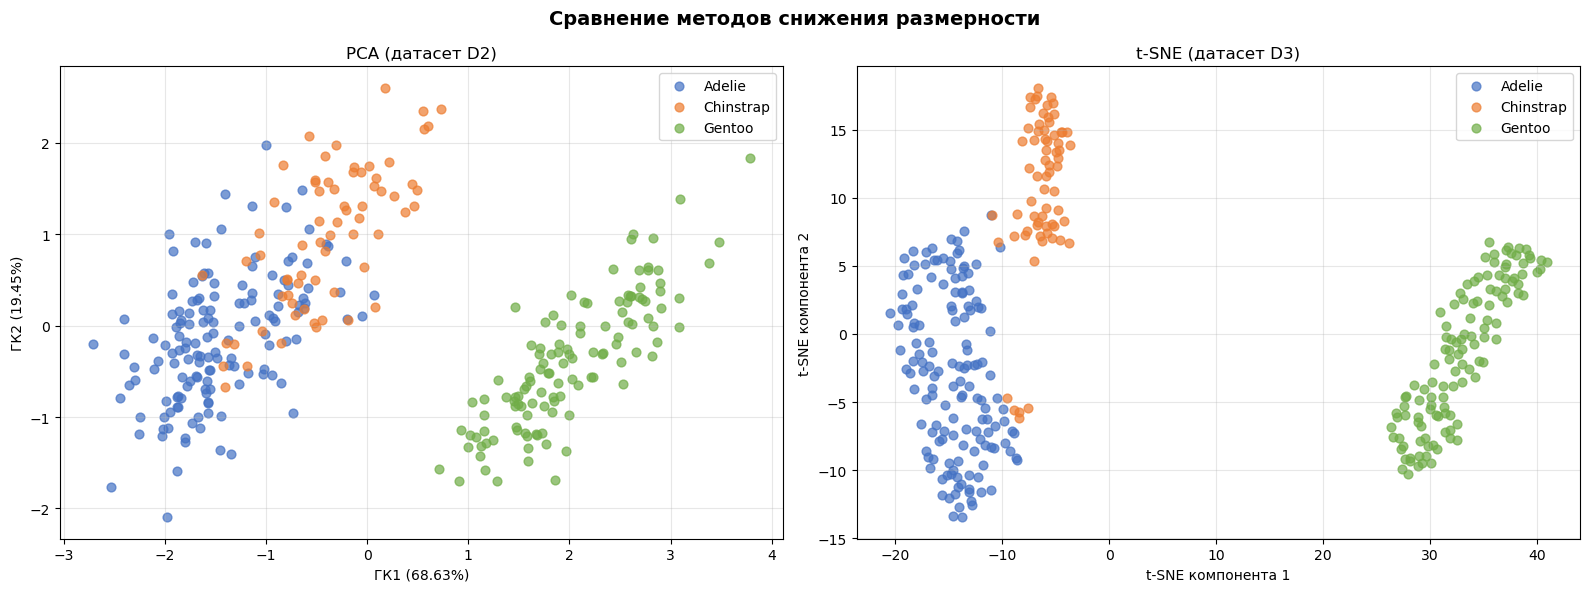

In [21]:
#применение t-sne для снижения размерности до 2 компонент
#random_state для воспроизводимости результатов
tsne = TSNE(n_components=2, random_state=0)
D3 = tsne.fit_transform(D1_scaled)

print(f'Размер датасета D3 (после t-SNE): {D3.shape}')

#визуализация результатов t-sne
fig, ax = plt.subplots(figsize=(8, 6))

for species in np.unique(y_true):
    mask = y_true == species
    ax.scatter(D3[mask, 0], D3[mask, 1], 
               label=species, 
               color=species_colors[species],
               alpha=0.7, s=40)

ax.set_xlabel('t-SNE компонента 1')
ax.set_ylabel('t-SNE компонента 2')
ax.set_title('t-SNE: снижение размерности до 2 компонент (датасет D3)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#cовместная визуализация pca и t-sne для сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#pca (d2)
for species in np.unique(y_true):
    mask = y_true == species
    axes[0].scatter(D2[mask, 0], D2[mask, 1], 
                    label=species, 
                    color=species_colors[species],
                    alpha=0.7, s=40)
axes[0].set_xlabel(f'ГК1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'ГК2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[0].set_title('PCA (датасет D2)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#t-sne (d3)
for species in np.unique(y_true):
    mask = y_true == species
    axes[1].scatter(D3[mask, 0], D3[mask, 1], 
                    label=species, 
                    color=species_colors[species],
                    alpha=0.7, s=40)
axes[1].set_xlabel('t-SNE компонента 1')
axes[1].set_ylabel('t-SNE компонента 2')
axes[1].set_title('t-SNE (датасет D3)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Сравнение методов снижения размерности', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5) Визуализация и сравнение датасетов D2 и D3.

На графиках представлены результаты снижения размерности датасета D1 до двух измерений методами PCA (D2) и t-SNE (D3). Точки раскрашены согласно истинным видам пингвинов.
Сравнение визуализаций показывает, что кластеры выделены наиболее явно в случае t-SNE (датасет D3). Все три вида пингвинов формируют компактные, хорошо отделённые группы с минимальным взаимным перекрытием. Gentoo образует изолированный кластер, значительно удалённый от двух других видов. Adélie и Chinstrap также разделены лучше, чем на графике PCA.
В случае PCA (датасет D2) кластеры также прослеживаются, однако Adélie и Chinstrap имеют заметную зону перекрытия, что затрудняет их однозначное разделение. Это объясняется линейной природой PCA: метод находит направления максимальной дисперсии, но не учитывает нелинейные закономерности в данных. t-SNE, напротив, сохраняет локальную структуру соседства точек в многомерном пространстве, что позволяет более точно воспроизвести естественные группировки объектов, даже если они не являются линейно разделимыми.

Таким образом, для задачи визуализации и выделения кластеров в данных о пингвинах t-SNE демонстрирует значительное преимущество перед PCA.

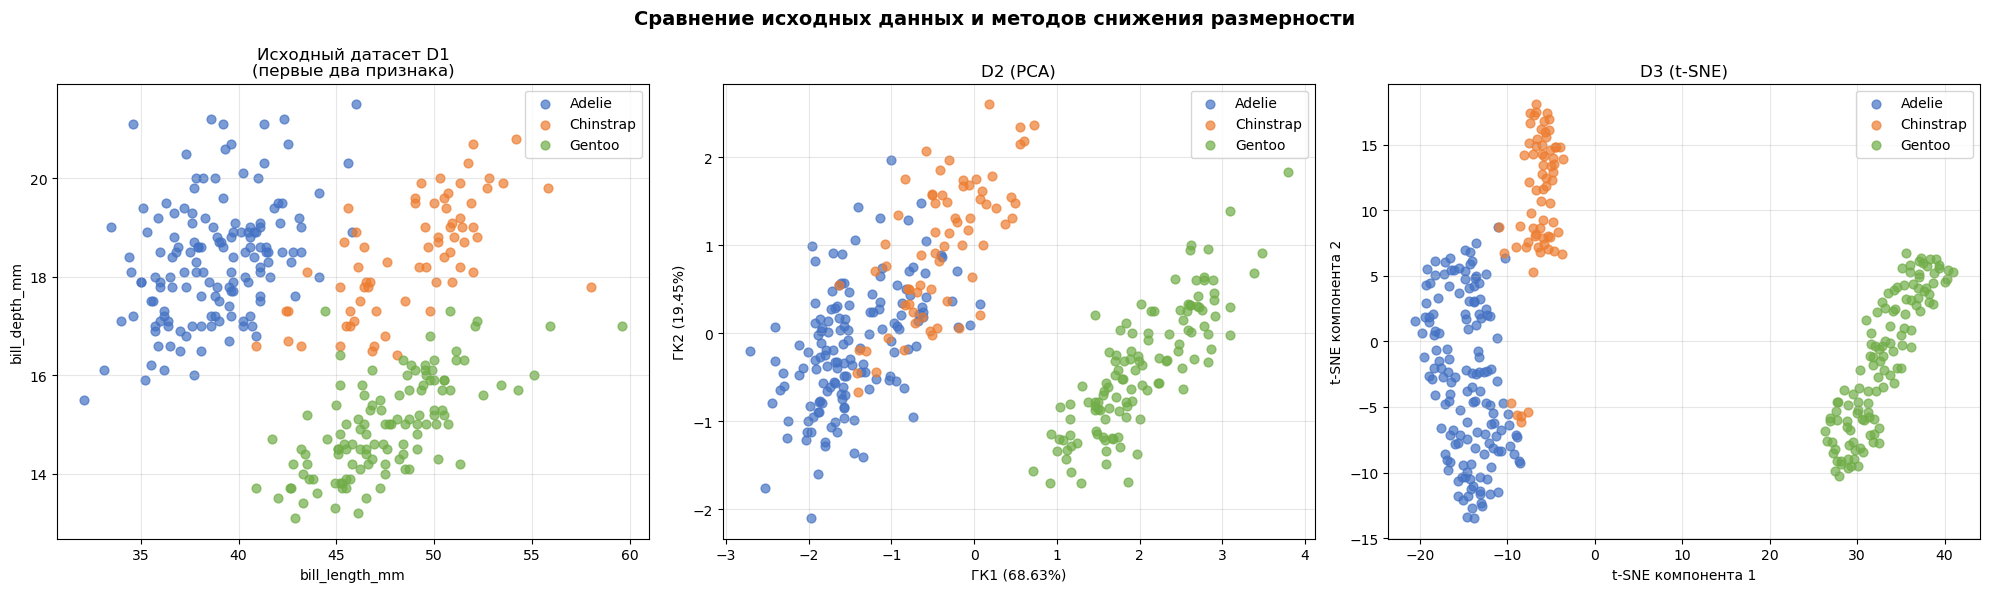

In [23]:
#cовместная визуализация d1 (первые два признака), d2 (psa) и d3 (t-sne)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

#d1 исходные данные (первые два признака bill_length_mm и bill_depth_mm)
for species in np.unique(y_true):
    mask = y_true == species
    axes[0].scatter(D1[mask, 0], D1[mask, 1], 
                    label=species, 
                    color=species_colors[species],
                    alpha=0.7, s=40)
axes[0].set_xlabel(feature_columns[0])
axes[0].set_ylabel(feature_columns[1])
axes[0].set_title('Исходный датасет D1\n(первые два признака)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#d2 
for species in np.unique(y_true):
    mask = y_true == species
    axes[1].scatter(D2[mask, 0], D2[mask, 1], 
                    label=species, 
                    color=species_colors[species],
                    alpha=0.7, s=40)
axes[1].set_xlabel(f'ГК1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'ГК2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[1].set_title('D2 (PCA)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

#d3 
for species in np.unique(y_true):
    mask = y_true == species
    axes[2].scatter(D3[mask, 0], D3[mask, 1], 
                    label=species, 
                    color=species_colors[species],
                    alpha=0.7, s=40)
axes[2].set_xlabel('t-SNE компонента 1')
axes[2].set_ylabel('t-SNE компонента 2')
axes[2].set_title('D3 (t-SNE)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle('Сравнение исходных данных и методов снижения размерности', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6) Кластеризация датасетов D1, D2 и D3.

Для каждого из трёх датасетов проведена кластеризация четырьмя методами: K-Means (k=3), агломеративная иерархическая кластеризация Agglomerative Clustering (k=3), Gaussian Mixture (n=3) и DBSCAN (eps=1.5, min_samples=5). Для методов, требующих задания числа кластеров, оно установлено равным трём, что соответствует числу истинных видов пингвинов. Качество кластеризации оценено с помощью метрик Adjusted Rand Index (ARI), Adjusted Mutual Information (AMI), Homogeneity, Completeness, V-measure и Silhouette Score. Результаты представлены в сводных таблицах.

1) Датасет D1 (исходные данные). Качество кластеризации на исходных данных сильно варьируется в зависимости от метода. Gaussian Mixture показал наилучший результат (ARI=0.959). K-Means (ARI=0.313) и Agglomerative Clustering (ARI=0.400) показали значительно худшие результаты, так как евклидово расстояние в исходном пространстве не позволяет корректно разделить перекрывающиеся виды. DBSCAN не смог выделить ни одного кластера (все 333 точки классифицированы как шум), что вызвано разным масштабом признаков и перекрытием облаков точек.

2) Датасет D2 (PCA). После снижения размерности методом PCA качество кластеризации для K-Means и Agglomerative Clustering существенно возросло: ARI увеличился с 0.31 до 0.72 и с 0.40 до 0.68 соответственно. Это объясняется тем, что PCA выделяет направления максимальной дисперсии, вдоль которых виды пингвинов лучше разделяются. Gaussian Mixture на D2, напротив, показал снижение качества (ARI = 0.687). DBSCAN на D2 выделил лишь один кластер, в котором все точки объединены, что говорит о недостаточной компактности кластеров в пространстве PCA для данного алгоритма.

3) Датасет D3 (t-SNE). Наилучшие результаты достигнуты именно на этом датасете. Agglomerative Clustering и Gaussian Mixture показали ARI = 0.943, DBSCAN ARI=0.928, K-Means ARI = 0.812. Высокое качество кластеризации объясняется тем, что t-SNE формирует компактные, хорошо изолированные кластеры, которые легко обнаруживаются даже простыми алгоритмами. DBSCAN на D3 успешно выделил все три кластера (8 точек классифицированы как шум). Значения V-measure (0.89–0.93) подтверждают, что кластеры одновременно содержат точки одного вида и все точки одного вида попадают в один кластер.



Кластеризация методом K-MEANS (k=3)



D1 (исходный):
  ARI = 0.3126, AMI = 0.4042
  Homogeneity = 0.4115, Completeness = 0.4038
  V-measure = 0.4076, Silhouette = 0.5589

D2 (PCA):
  ARI = 0.7227, AMI = 0.7319
  Homogeneity = 0.7464, Completeness = 0.7209
  V-measure = 0.7334, Silhouette = 0.5364

D3 (t-SNE):
  ARI = 0.8125, AMI = 0.7973
  Homogeneity = 0.8089, Completeness = 0.7884
  V-measure = 0.7985, Silhouette = 0.6399


Кластеризация методом AGGLOMERATIVE CLUSTERING (k=3)



D1 (исходный):
  ARI = 0.4000, AMI = 0.4060
  Homogeneity = 0.4141, Completeness = 0.4048
  V-measure = 0.4094, Silhouette = 0.5164

D2 (PCA):
  ARI = 0.6771, AMI = 0.7149
  Homogeneity = 0.7313, Completeness = 0.7022
  V-measure = 0.7165, Silhouette = 0.5179

D3 (t-SNE):
  ARI = 0.9435, AMI = 0.9263
  Homogeneity = 0.9190, Completeness = 0.9347
  V-measure = 0.9267, Silhouette = 0.6531


Кластеризация методом GAUSSIAN MIXTURE (n=3)



D1 (исходный):
  ARI = 0.9590, AMI = 0.9333
  Homogeneity = 0.9326, Com

,Датасет,K-Means,Agglomerative,GaussianMixture,DBSCAN
0,D1 (исходный),0.312635,0.400046,0.958996,0.000000
1,D2 (PCA),0.722703,0.677084,0.686622,0.000000
2,D3 (t-SNE),0.812485,0.943465,0.943465,0.927763




Сравнение методов по SILHOUETTE




,Датасет,K-Means,Agglomerative,GaussianMixture,DBSCAN
0,D1 (исходный),0.558921,0.516414,0.146328,NaN
1,D2 (PCA),0.536386,0.517886,0.502725,NaN
2,D3 (t-SNE),0.639886,0.653099,0.653099,0.591534


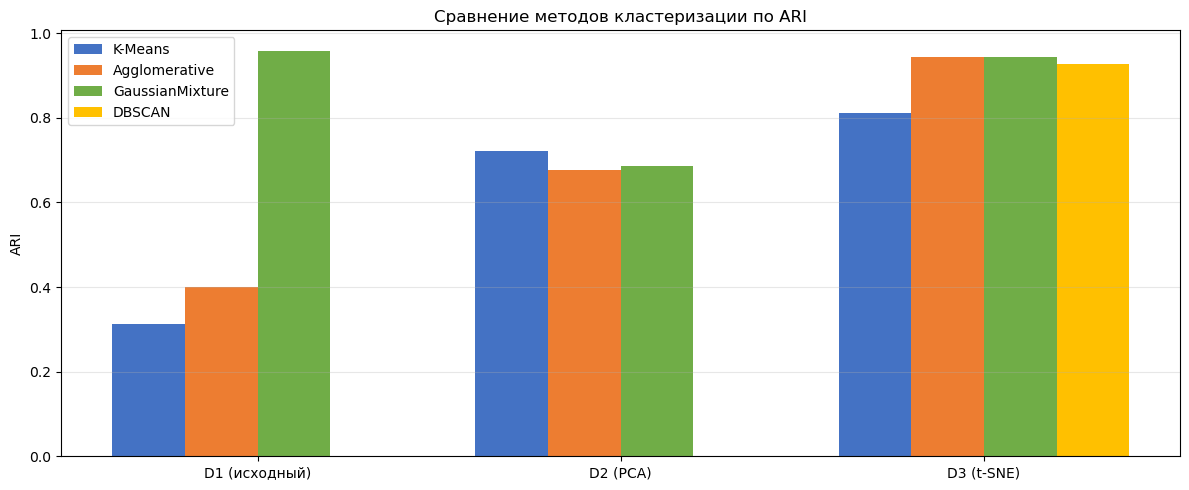

In [35]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics import homogeneity_completeness_v_measure, silhouette_score

#список датасетов для кластеризации
datasets = {
    'D1 (исходный)': D1,
    'D2 (PCA)': D2, 
    'D3 (t-SNE)': D3
}

#функция для вычисления метрик кластеризации
def evaluate_clustering(data, labels_true, labels_pred):
    ari = adjusted_rand_score(labels_true, labels_pred)
    ami = adjusted_mutual_info_score(labels_true, labels_pred)
    h, c, v = homogeneity_completeness_v_measure(labels_true, labels_pred)
    
#силуэт может не вычислиться (если один кластер)
    try:
        sil = silhouette_score(data, labels_pred)
    except:
        sil = np.nan
    
    return {'ARI': ari, 'AMI': ami, 'Homogeneity': h, 
            'Completeness': c, 'V-measure': v, 'Silhouette': sil}


#k-means с 3 кластерами (по числу видов)
print('\n')
print('Кластеризация методом K-MEANS (k=3)')
print('\n')

results_kmeans = []

for name, data in datasets.items():
    kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(data)
    metrics = evaluate_clustering(data, y_true, labels)
    metrics['Dataset'] = name
    results_kmeans.append(metrics)
    
    print(f'\n{name}:')
    print(f'  ARI = {metrics["ARI"]:.4f}, AMI = {metrics["AMI"]:.4f}')
    print(f'  Homogeneity = {metrics["Homogeneity"]:.4f}, Completeness = {metrics["Completeness"]:.4f}')
    print(f'  V-measure = {metrics["V-measure"]:.4f}, Silhouette = {metrics["Silhouette"]:.4f}')

df_kmeans = pd.DataFrame(results_kmeans)


print('\n')
print('Кластеризация методом AGGLOMERATIVE CLUSTERING (k=3)')
print('\n')

results_agg = []

for name, data in datasets.items():
    agg = AgglomerativeClustering(n_clusters=3)
    labels = agg.fit_predict(data)
    metrics = evaluate_clustering(data, y_true, labels)
    metrics['Dataset'] = name
    results_agg.append(metrics)
    
    print(f'\n{name}:')
    print(f'  ARI = {metrics["ARI"]:.4f}, AMI = {metrics["AMI"]:.4f}')
    print(f'  Homogeneity = {metrics["Homogeneity"]:.4f}, Completeness = {metrics["Completeness"]:.4f}')
    print(f'  V-measure = {metrics["V-measure"]:.4f}, Silhouette = {metrics["Silhouette"]:.4f}')

df_agg = pd.DataFrame(results_agg)


print('\n')
print('Кластеризация методом GAUSSIAN MIXTURE (n=3)')
print('\n')

results_gmm = []

for name, data in datasets.items():
    gmm = GaussianMixture(n_components=3, random_state=0)
    labels = gmm.fit_predict(data)
    metrics = evaluate_clustering(data, y_true, labels)
    metrics['Dataset'] = name
    results_gmm.append(metrics)
    
    print(f'\n{name}:')
    print(f'  ARI = {metrics["ARI"]:.4f}, AMI = {metrics["AMI"]:.4f}')
    print(f'  Homogeneity = {metrics["Homogeneity"]:.4f}, Completeness = {metrics["Completeness"]:.4f}')
    print(f'  V-measure = {metrics["V-measure"]:.4f}, Silhouette = {metrics["Silhouette"]:.4f}')

df_gmm = pd.DataFrame(results_gmm)



print('\n')
print('Кластеризация методом DBSCAN')
print('\n')

results_dbscan = []

for name, data in datasets.items():
    dbscan = DBSCAN(eps=1.5, min_samples=5)
    labels = dbscan.fit_predict(data)
    metrics = evaluate_clustering(data, y_true, labels)
    metrics['Dataset'] = name
    results_dbscan.append(metrics)
    
    n_clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    print(f'\n{name}:')
    print(f'  Количество кластеров: {n_clusters}, шумовых точек: {n_noise}')
    print(f'  ARI = {metrics["ARI"]:.4f}, AMI = {metrics["AMI"]:.4f}')
    print(f'  Homogeneity = {metrics["Homogeneity"]:.4f}, Completeness = {metrics["Completeness"]:.4f}')
    print(f'  V-measure = {metrics["V-measure"]:.4f}, Silhouette = {metrics["Silhouette"]:.4f}')

df_dbscan = pd.DataFrame(results_dbscan)



#сводная таблица сравнение ari для всех методов и датасетов
print('\n')
print('Сравнение методов по ARI (Adjusted Rand Index)')
print('\n')

comparison_ari = pd.DataFrame({
    'Датасет': ['D1 (исходный)', 'D2 (PCA)', 'D3 (t-SNE)'],
    'K-Means': [r['ARI'] for r in results_kmeans],
    'Agglomerative': [r['ARI'] for r in results_agg],
    'GaussianMixture': [r['ARI'] for r in results_gmm],
    'DBSCAN': [r['ARI'] for r in results_dbscan]
})
display(comparison_ari)

#сводная таблица сравнение Silhouett
print('\n')
print('Сравнение методов по SILHOUETTE')
print('\n')

comparison_sil = pd.DataFrame({
    'Датасет': ['D1 (исходный)', 'D2 (PCA)', 'D3 (t-SNE)'],
    'K-Means': [r['Silhouette'] for r in results_kmeans],
    'Agglomerative': [r['Silhouette'] for r in results_agg],
    'GaussianMixture': [r['Silhouette'] for r in results_gmm],
    'DBSCAN': [r['Silhouette'] for r in results_dbscan]
})
display(comparison_sil)

#визуализация
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(3)
width = 0.2
ax.bar(x - 1.5*width, comparison_ari['K-Means'], width, label='K-Means', color='#4472C4')
ax.bar(x - 0.5*width, comparison_ari['Agglomerative'], width, label='Agglomerative', color='#ED7D31')
ax.bar(x + 0.5*width, comparison_ari['GaussianMixture'], width, label='GaussianMixture', color='#70AD47')
ax.bar(x + 1.5*width, comparison_ari['DBSCAN'], width, label='DBSCAN', color='#FFC000')
ax.set_xticks(x)
ax.set_xticklabels(comparison_ari['Датасет'])
ax.set_ylabel('ARI')
ax.set_title('Сравнение методов кластеризации по ARI')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

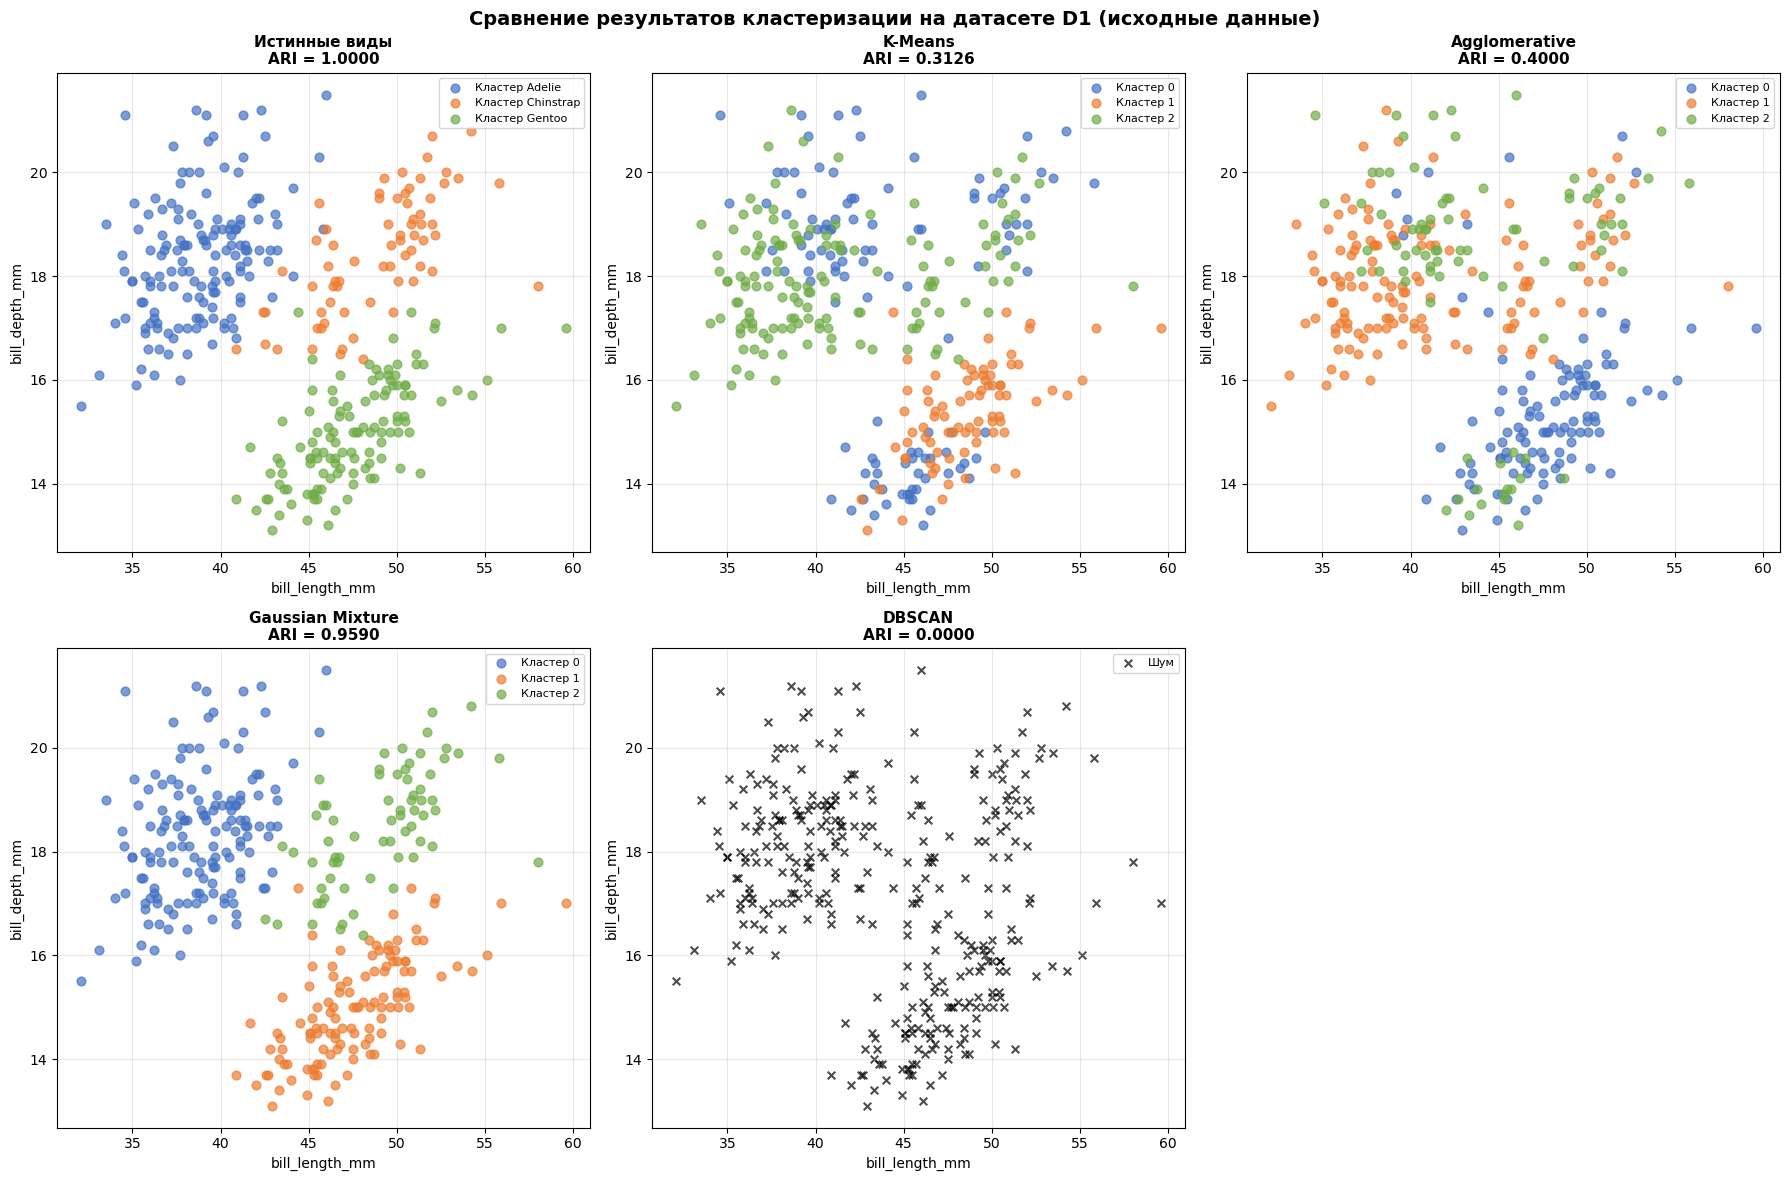

In [29]:
#визуализация результатов всех методов кластеризации на d1 (исходный)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

cluster_colors = np.array(['#4472C4', '#ED7D31', '#70AD47', '#FFC000', '#A5A5A5', '#5B9BD5'])

clustering_results_d1 = {
    'Истинные виды': y_true,
    'K-Means': KMeans(n_clusters=3, random_state=0, n_init='auto').fit_predict(D1),
    'Agglomerative': AgglomerativeClustering(n_clusters=3).fit_predict(D1),
    'Gaussian Mixture': GaussianMixture(n_components=3, random_state=0).fit_predict(D1),
    'DBSCAN': DBSCAN(eps=1.5, min_samples=5).fit_predict(D1)
}

for ax, (name, labels) in zip(axes.flatten(), clustering_results_d1.items()):
    unique_labels = np.unique(labels)
    for i, label in enumerate(unique_labels):
        if label == -1:
            color, marker, size, label_text = '#000000', 'x', 30, 'Шум'
        else:
            color = cluster_colors[i % len(cluster_colors)]
            marker, size, label_text = 'o', 40, f'Кластер {label}'
        
        mask = labels == label
        ax.scatter(D1[mask, 0], D1[mask, 1], 
                   color=color, marker=marker, s=size, alpha=0.7,
                   label=label_text)
    
    ari = adjusted_rand_score(y_true, labels)
    ax.set_title(f'{name}\nARI = {ari:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(feature_columns[0])
    ax.set_ylabel(feature_columns[1])
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

axes[1, 2].set_visible(False)

fig.suptitle('Сравнение результатов кластеризации на датасете D1 (исходные данные)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

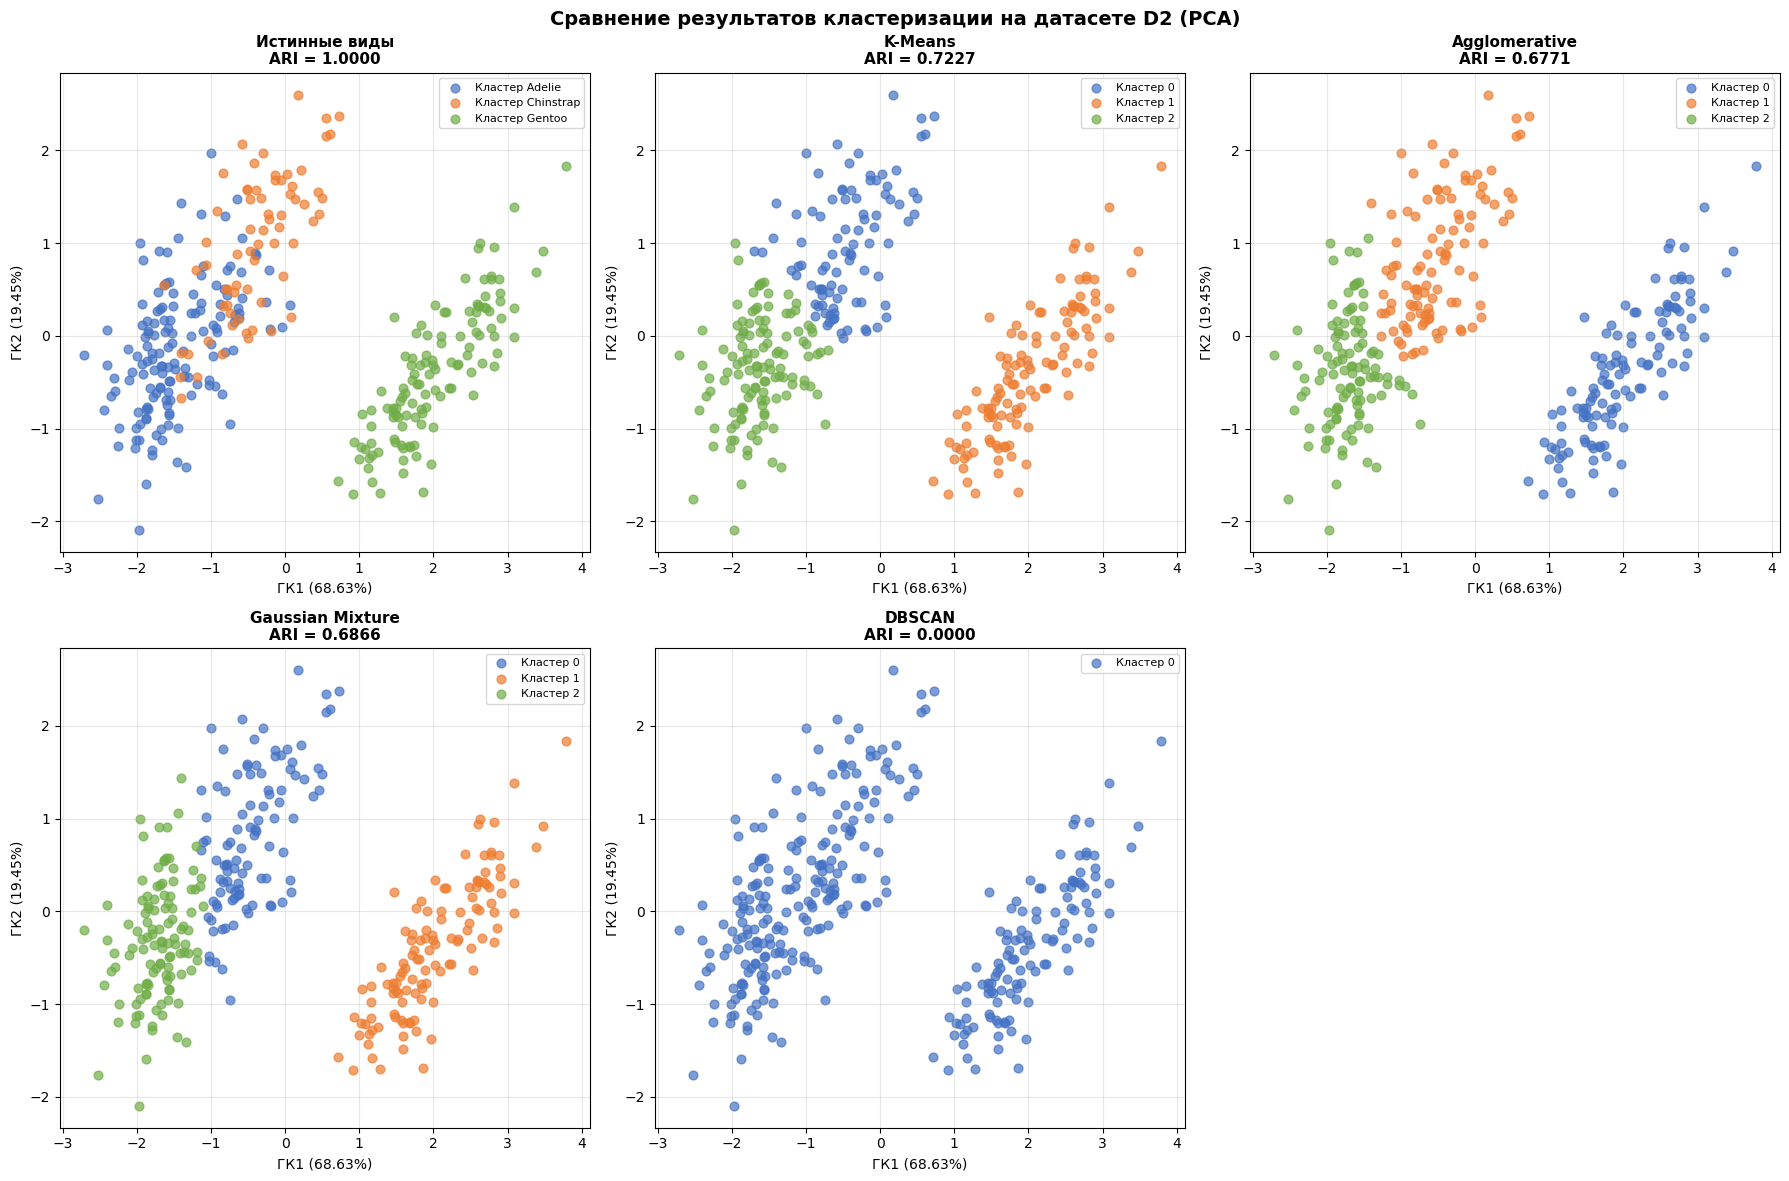

In [31]:
#визуализация результатов всех методов кластеризации на d2 
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

clustering_results_d2 = {
    'Истинные виды': y_true,
    'K-Means': KMeans(n_clusters=3, random_state=0, n_init='auto').fit_predict(D2),
    'Agglomerative': AgglomerativeClustering(n_clusters=3).fit_predict(D2),
    'Gaussian Mixture': GaussianMixture(n_components=3, random_state=0).fit_predict(D2),
    'DBSCAN': DBSCAN(eps=1.5, min_samples=5).fit_predict(D2)
}

for ax, (name, labels) in zip(axes.flatten(), clustering_results_d2.items()):
    unique_labels = np.unique(labels)
    for i, label in enumerate(unique_labels):
        if label == -1:
            color, marker, size, label_text = '#000000', 'x', 30, 'Шум'
        else:
            color = cluster_colors[i % len(cluster_colors)]
            marker, size, label_text = 'o', 40, f'Кластер {label}'
        
        mask = labels == label
        ax.scatter(D2[mask, 0], D2[mask, 1], 
                   color=color, marker=marker, s=size, alpha=0.7,
                   label=label_text)
    
    ari = adjusted_rand_score(y_true, labels)
    ax.set_title(f'{name}\nARI = {ari:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'ГК1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'ГК2 ({pca.explained_variance_ratio_[1]:.2%})')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

axes[1, 2].set_visible(False)

fig.suptitle('Сравнение результатов кластеризации на датасете D2 (PCA)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

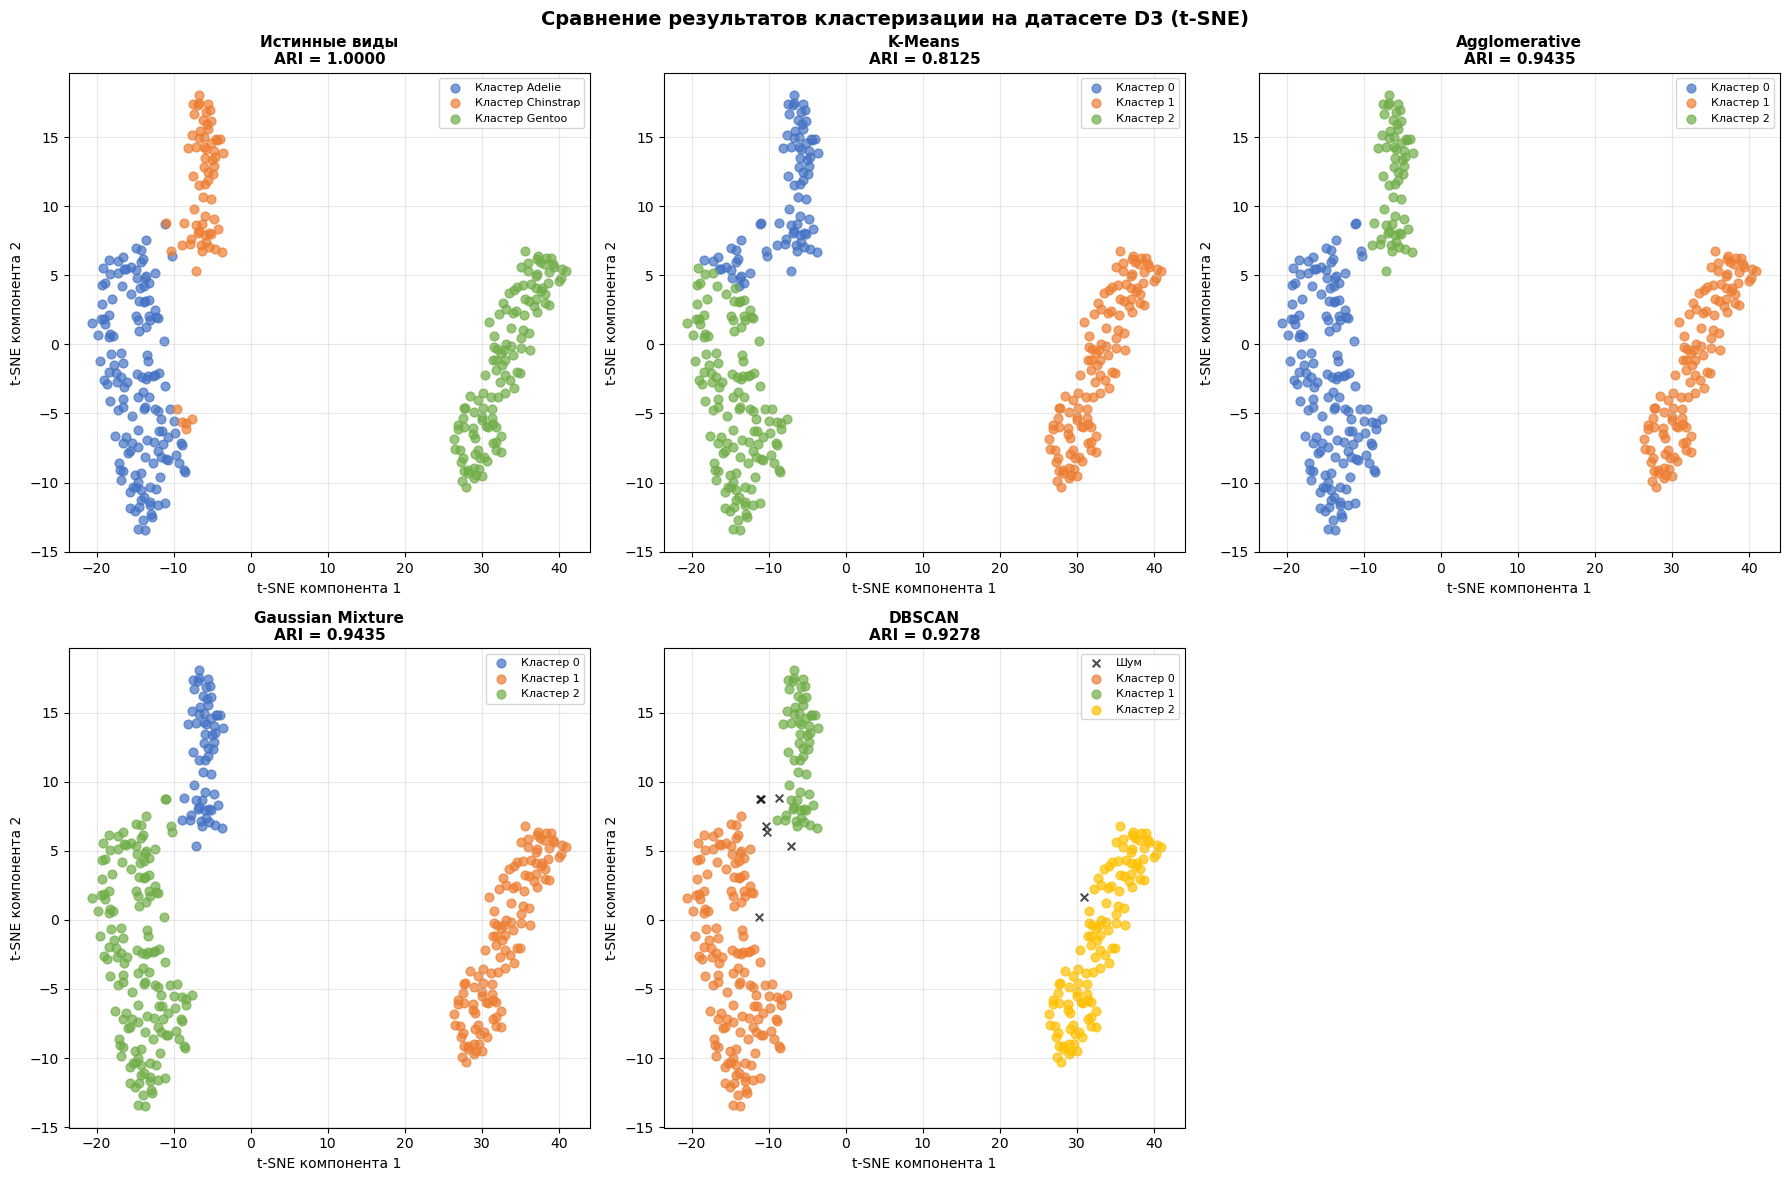

In [33]:
#визуализация результатов всех методов кластеризации на d3 
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

#цветовая схема для кластеров
cluster_colors = np.array(['#4472C4', '#ED7D31', '#70AD47', '#FFC000', '#A5A5A5', '#5B9BD5'])

#список результатов кластеризации 
clustering_results = {
    'Истинные виды': y_true,
    'K-Means': KMeans(n_clusters=3, random_state=0, n_init='auto').fit_predict(D3),
    'Agglomerative': AgglomerativeClustering(n_clusters=3).fit_predict(D3),
    'Gaussian Mixture': GaussianMixture(n_components=3, random_state=0).fit_predict(D3),
    'DBSCAN': DBSCAN(eps=1.5, min_samples=5).fit_predict(D3)
}

for ax, (name, labels) in zip(axes.flatten(), clustering_results.items()):
    unique_labels = np.unique(labels)
    for i, label in enumerate(unique_labels):
        if label == -1:
            color, marker, size, label_text = '#000000', 'x', 30, 'Шум'
        else:
            color = cluster_colors[i % len(cluster_colors)]
            marker, size, label_text = 'o', 40, f'Кластер {label}'
        
        mask = labels == label
        ax.scatter(D3[mask, 0], D3[mask, 1], 
                   color=color, marker=marker, s=size, alpha=0.7,
                   label=label_text)
    
    ari = adjusted_rand_score(y_true, labels)
    ax.set_title(f'{name}\nARI = {ari:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE компонента 1')
    ax.set_ylabel('t-SNE компонента 2')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

#убираем лишнюю пустую ячейку
axes[1, 2].set_visible(False)

fig.suptitle('Сравнение результатов кластеризации на датасете D3 (t-SNE)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7) Выбор лучшего метода кластеризации для каждого датасета

Проведённый сравнительный анализ позволяет сделать следующие выводы о наилучших методах кластеризации для каждого датасета:

1) Для датасета D1 (исходные данные) лучшим методом оказался Gaussian Mixture (ARI=0.959, V-measure=0.934). Это объясняется тем, что Gaussian Mixture моделирует кластеры как многомерные нормальные распределения с учётом ковариационной матрицы, что позволяет ему корректно выделять кластеры в исходном четырёхмерном пространстве даже при наличии перекрытия между ними. Остальные методы (K-Means, Agglomerative Clustering) используют евклидово расстояние, которое в пространстве нестандартизированных признаков с разным масштабом (миллиметры и граммы) работает некорректно, что приводит к низкому качеству кластеризации. DBSCAN на D1 полностью не справился с задачей из-за перекрытия кластеров и разного масштаба признаков.

2) Для датасета D2 (PCA) лучшим методом оказался K-Means (ARI=0.723, V-measure=0.733). После стандартизации и снижения размерности методом PCA кластеры стали лучше разделимы в направлении главных компонент. K-Means показал наилучший результат, так как PCA формирует линейно разделимые проекции, а K-Means эффективно находит центроиды в таком пространстве. Agglomerative Clustering показал близкий результат (ARI=0.677), а Gaussian Mixture заметно уступил (ARI=0.687), поскольку в двумерном пространстве PCA кластеры стали менее соответствовать форме многомерного нормального распределения, чем в исходном четырёхмерном пространстве. DBSCAN на D2 вновь не справился и выделил лишь один кластер, что говорит о недостаточной компактности данных в пространстве главных компонент.

3) Для датасета D3 (t-SNE) лучшими методами оказались Agglomerative Clustering и Gaussian Mixture (ARI=0.943, V-measure=0.927). t-SNE, в отличие от PCA, сохраняет локальную структуру данных и формирует компактные, хорошо изолированные кластеры без взаимного перекрытия. В таких условиях агломеративная кластеризация, последовательно объединяющая ближайшие точки, и Gaussian Mixture, моделирующий компактные эллиптические кластеры, достигают хорошего совпадения с истинными видами пингвинов. DBSCAN также показал отличный результат (ARI=0.928), поскольку компактные кластеры D3 соответствуют его модели, то есть области с высокой плотностью точек, разделённые областями с низкой плотностью. K-Means на D3 показал результат немного хуже (ARI=0.812).



## Вывод

В ходе выполнения лабораторной работы были изучены методы обучения без учителя: снижение размерности (PCA, t-SNE) и кластеризация (K-Means, Agglomerative Clustering, Gaussian Mixture, DBSCAN) на примере датасета Penguins. Сравнение PCA и t-SNE показало, что нелинейный метод t-SNE обеспечивает значительно более компактные и хорошо разделимые кластеры, чем линейный PCA, что делает его предпочтительным для задач визуализации и подготовки данных к кластеризации. Кластеризация на исходном датасете D1 выявила преимущество Gaussian Mixture перед остальными методами, так как он учитывает ковариационную структуру и форму кластеров, а не только расстояния до центроидов. На датасете D2 (PCA) лучшим оказался K-Means, поскольку главные компоненты формируют линейно разделимое пространство, в котором эффективно работают метрические алгоритмы. Наилучшие результаты достигнуты на датасете D3 (t-SNE), где агломеративная кластеризация и Gaussian Mixture показали отличное совпадение с истинными видами пингвинов (ARI=0.94), а DBSCAN впервые успешно выделил все три кластера. Таким образом, комбинация t-SNE для снижения размерности с последующей агломеративной кластеризацией или Gaussian Mixture является оптимальной стратегией для выявления естественной группировки объектов в многомерных данных.

